# TRAIN TEST SPLIT

In [57]:
from sklearn import linear_model
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split

In [40]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.preprocessing import OneHotEncoder

In [41]:
data=pd.read_csv('carprices_ML.csv')
data

,Mileage,Age(yrs),Sell Price($)
0,69000,6,18000
1,35000,3,34000
2,57000,5,26100
3,22500,2,40000
4,46000,4,31500
5,59000,5,26750
6,52000,5,32000
7,72000,6,19300
8,91000,8,12000
9,67000,6,22000


In [42]:
data.head()

,Mileage,Age(yrs),Sell Price($)
0,69000,6,18000
1,35000,3,34000
2,57000,5,26100
3,22500,2,40000
4,46000,4,31500


In [43]:
data.tail()

,Mileage,Age(yrs),Sell Price($)
15,25400,3,35000
16,28000,2,35500
17,69000,5,19700
18,87600,8,12800
19,52000,5,28200


In [44]:
data.dtypes

Mileage          int64
Age(yrs)         int64
Sell Price($)    int64
dtype: object

In [45]:
data.isna().sum()

Mileage          0
Age(yrs)         0
Sell Price($)    0
dtype: int64

In [46]:
data.duplicated().sum()

np.int64(0)

In [47]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Mileage        20 non-null     int64
 1   Age(yrs)       20 non-null     int64
 2   Sell Price($)  20 non-null     int64
dtypes: int64(3)
memory usage: 612.0 bytes


In [48]:
data.describe()

,Mileage,Age(yrs),Sell Price($)
count,20.000000,20.000000,20.000000
mean,59736.500000,5.150000,25197.500000
std,20595.441825,1.785173,7834.479713
min,22500.000000,2.000000,12000.000000
25%,50500.000000,4.000000,19375.000000
50%,59000.000000,5.000000,26050.000000
75%,73750.000000,6.250000,31625.000000
max,91000.000000,8.000000,40000.000000


In [49]:
correlation=data[['Mileage','Age(yrs)','Sell Price($)']].corr()
correlation

,Mileage,Age(yrs),Sell Price($)
Mileage,1.000000,0.968290,-0.967173
Age(yrs),0.968290,1.000000,-0.941522
Sell Price($),-0.967173,-0.941522,1.000000


<Axes: >

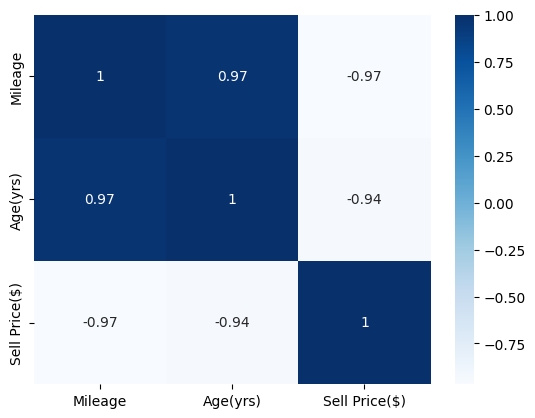

In [50]:
sns.heatmap(correlation,annot=True,cmap='Blues')

In [51]:
x=data.drop('Sell Price($)',axis=1)
x

,Mileage,Age(yrs)
0,69000,6
1,35000,3
2,57000,5
3,22500,2
4,46000,4
5,59000,5
6,52000,5
7,72000,6
8,91000,8
9,67000,6


In [52]:
y=data['Sell Price($)']
y

0     18000
1     34000
2     26100
3     40000
4     31500
5     26750
6     32000
7     19300
8     12000
9     22000
10    18700
11    19500
12    26000
13    27500
14    19400
15    35000
16    35500
17    19700
18    12800
19    28200
Name: Sell Price($), dtype: int64

In [61]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)
#test_size=0.3=this specifiyes the propostion of dataset to include in the test 
#here 30% of the data will be used fotb testing and the remaining 70% will be used fotr training

In [59]:
#x_train:-the training subset of your feature
#x_test:-the testing subset of your feature
#y_train:-the training subset of your target
#x_train:-the testing subset of your target

In [62]:
model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ -0.35,-178.19]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Mileage','Age(yrs)']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.713e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2


In [63]:
x_test

,Mileage,Age(yrs)
10,83000,7
3,22500,2
18,87600,8
16,28000,2
2,57000,5
12,59000,5


In [67]:
y_test   #the test subset of your target value

10    18700
3     40000
18    12800
16    35500
2     26100
12    26000
Name: Sell Price($), dtype: int64

In [68]:
model.predict([[34550,9]])

c:\Users\adith\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([33369.65723517])

In [73]:
model.score(x_train,y_train)

0.9015219540560434

In [69]:
model.score(x_test,y_test) #method computes the accuracy of the model

0.9765218046284707

In [ ]:
predicted_value=model.predict(x_test)
predicted_value

array([16675.83713124, 38857.51490019, 14878.85029165, 36921.99250978,
       26181.95193023, 25478.12560644])

In [71]:
actual_value=y_test
actual_value

10    18700
3     40000
18    12800
16    35500
2     26100
12    26000
Name: Sell Price($), dtype: int64

In [ ]:
result=pd.DataFrame({'actualvalue': y_test,
              'predictedvalue': predicted_value})
              
result

,actualvalue,predictedvalue
10,18700,16675.837131
3,40000,38857.514900
18,12800,14878.850292
16,35500,36921.992510
2,26100,26181.951930
12,26000,25478.125606


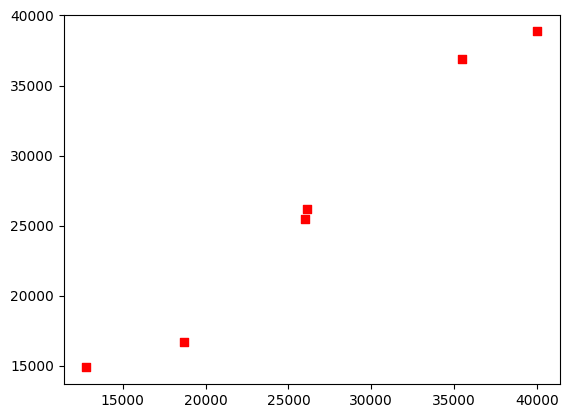

In [72]:
plt.scatter(actual_value,predicted_value,marker='s',color='red')

In [82]:
a=mean_squared_error(y_test,predicted_value)
a 

2004209.626169665

In [ ]:
mean_absolute_error(y_test,predicted_value)


1211.8861822967476

In [83]:
np.sqrt(a)

np.float64(1415.7011076387787)